# Answer-Containment Retrieval Performance
Compare overall and popularity-stratified Answer Recall@K and Answer MRR.

In [1]:
import sys
from pathlib import Path
repo_root = Path.cwd().resolve()
if repo_root.name == 'retrieval_answer_eval': repo_root = repo_root.parents[1]
sys.path.insert(0, str(repo_root))
from notebooks.retrieval_answer_eval.shared_setup import *
display(metrics_by_strategy)

,n_questions,answer_mrr,answer_recall@1,answer_recall@3,answer_recall@5,answer_recall@10
backend,,,,,,
BM25+,4729,0.377006,0.314443,0.423980,0.459505,0.502643
FAISS high,4729,0.413958,0.345739,0.461831,0.504546,0.557623
FAISS hybrid,4729,0.375765,0.264115,0.464157,0.532036,0.587651


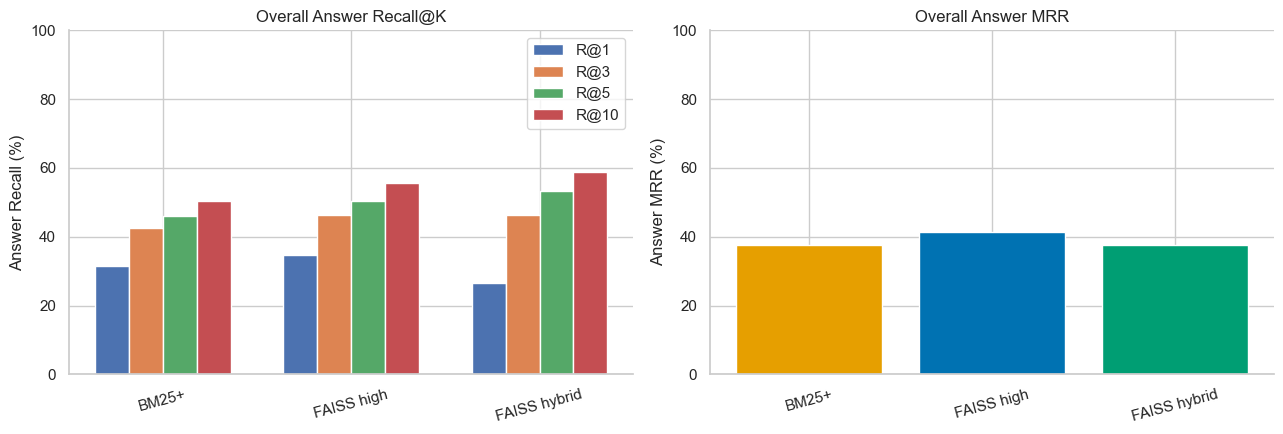

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(ALL_STRATEGIES)); width = 0.18
for index, k in enumerate(K_VALUES_DETAILED):
    values = [results_by_strategy[key][f'recall@{k}'].mean() * 100 for key in ALL_STRATEGIES]
    axes[0].bar(x + (index - 1.5) * width, values, width, label=f'R@{k}')
axes[0].set_xticks(x, [strategy_label(key) for key in ALL_STRATEGIES], rotation=15)
axes[0].set(ylabel='Answer Recall (%)', title='Overall Answer Recall@K', ylim=(0, 100)); axes[0].legend()
mrr = [results_by_strategy[key]['reciprocal_rank'].mean() * 100 for key in ALL_STRATEGIES]
axes[1].bar([strategy_label(key) for key in ALL_STRATEGIES], mrr, color=[strategy_color(key) for key in ALL_STRATEGIES])
axes[1].set(ylabel='Answer MRR (%)', title='Overall Answer MRR', ylim=(0, 100)); axes[1].tick_params(axis='x', rotation=15)
for ax in axes: ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); fig.savefig(IMAGES_DIR / 'answer_performance_overview.png', dpi=300, bbox_inches='tight'); plt.show()

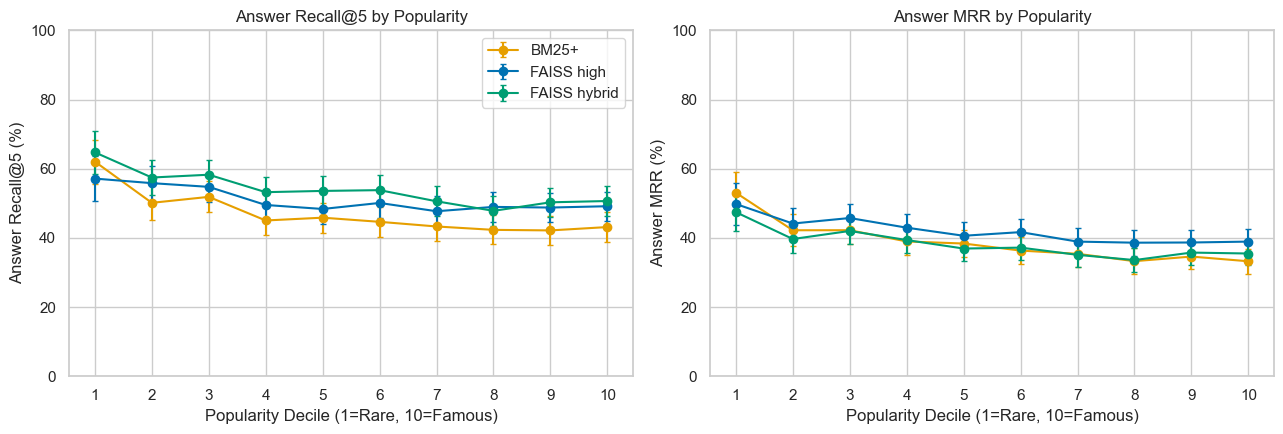

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for key, frame in results_by_strategy.items():
    summary = frame.groupby('decile').agg(recall=(f'recall@{TOP_K}', 'mean'), recall_sem=(f'recall@{TOP_K}', 'sem'), mrr=('reciprocal_rank', 'mean'), mrr_sem=('reciprocal_rank', 'sem')).reset_index()
    for ax, metric, sem, label in [(axes[0], 'recall', 'recall_sem', f'Answer Recall@{TOP_K}'), (axes[1], 'mrr', 'mrr_sem', 'Answer MRR')]:
        ax.errorbar(summary['decile'] + 1, summary[metric] * 100, yerr=1.96 * summary[sem] * 100, marker='o', capsize=2, label=strategy_label(key), color=strategy_color(key))
        ax.set(title=f'{label} by Popularity', xlabel='Popularity Decile (1=Rare, 10=Famous)', ylabel=f'{label} (%)', xticks=range(1, 11), ylim=(0, 100))
axes[0].legend(); fig.tight_layout(); fig.savefig(IMAGES_DIR / 'answer_per_decile_performance.png', dpi=300, bbox_inches='tight'); plt.show()

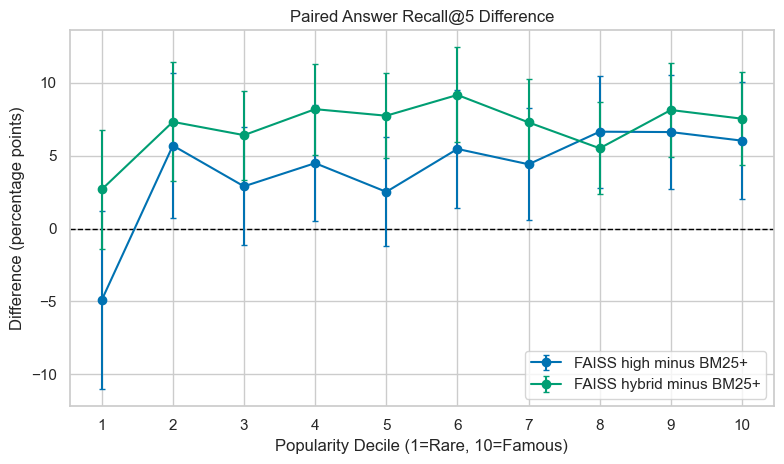

In [4]:
baseline_key = 'bm25_plus'
baseline = results_by_strategy[baseline_key][['question_id', 'decile', f'recall@{TOP_K}']]
fig, ax = plt.subplots(figsize=(8, 4.8)); ax.axhline(0, color='black', linestyle='--', linewidth=1)
for key in [value for value in ALL_STRATEGIES if value != baseline_key]:
    paired = baseline.merge(results_by_strategy[key][['question_id', f'recall@{TOP_K}']], on='question_id', suffixes=('_baseline', '_comparison'), validate='one_to_one')
    paired['delta'] = paired[f'recall@{TOP_K}_comparison'] - paired[f'recall@{TOP_K}_baseline']
    summary = paired.groupby('decile')['delta'].agg(['mean', 'sem']).reset_index()
    ax.errorbar(summary['decile'] + 1, summary['mean'] * 100, yerr=1.96 * summary['sem'] * 100, marker='o', capsize=2, label=f'{strategy_label(key)} minus BM25+', color=strategy_color(key))
ax.set(title=f'Paired Answer Recall@{TOP_K} Difference', xlabel='Popularity Decile (1=Rare, 10=Famous)', ylabel='Difference (percentage points)', xticks=range(1, 11)); ax.legend()
fig.tight_layout(); fig.savefig(IMAGES_DIR / f'answer_recall_at_{TOP_K}_paired_delta.png', dpi=300, bbox_inches='tight'); plt.show()